# このノートブックについて

このノートブックでは前回のノートブックで実装及び学習による性能評価を完了したCareFLを用いて介入分布からの生成と反事実推論を行っていくことを目的としたノートブックである。

# 1. CareFLを用いた介入分布からの生成

In [1]:
import os

os.chdir('/home/hashikami/projects/Diff')

## 1.1 介入分布からの生成実装

In [44]:
import importlib 
from carefl.models import carefl

importlib.reload(carefl)

from carefl.models.carefl import CAREFL
import yaml
import argparse

with open('config/config.yaml', 'r') as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
    
def dict2namespace(config):
    namespace = argparse.Namespace()
    for key, value in config.items():
        if isinstance(value, dict):
            new_value = dict2namespace(value)
        else:
            new_value = value
        setattr(namespace, key, new_value)
    return namespace

config = dict2namespace(config_raw)
carefl = CAREFL(config)

In [45]:
flow, loss_vals = carefl._train()

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:25<00:00,  7.89it/s]


In [46]:
carefl.B_true

array([[0., 1., 1.],
       [0., 0., 0.],
       [0., 1., 0.]])

In [24]:
def predict_intervention(carefl, int_idx, int_val, n_samples=100):
    
    if isinstance(int_idx, (int, np.integer)):
        int_idx = [int_idx]
    if np.isscalar(int_val):
        int_val = [float(int_val)]
    assert len(int_idx) == len(int_val)

    int_idx = list(int_idx)
    int_val = list(int_val)
    device = carefl.device
    
    flows = carefl.flow.flow.flows
    z = carefl.flow.prior.sample((n_samples,)).to(device)
    for affine in flows[::-1]:
        trans_idx = affine.trans_idx[0]
        if trans_idx in int_idx:
            z[:, trans_idx] = int_val[int_idx.index(trans_idx)]
        else:
            z, _ = affine.backward(z)
            
    return z

In [42]:
import numpy as np

int_idx = 1
int_val = 3.0
x = predict_intervention(carefl, int_idx, int_val, n_samples=1000)

In [43]:
x.mean(0)

tensor([0.0894, 3.0000, 3.6989], device='cuda:0', grad_fn=<MeanBackward1>)

In [36]:
xs = carefl.flow.sample(1000)
x = xs[-1]
x.mean(0)

tensor([ 0.0216, -0.1451,  0.1216], device='cuda:0', grad_fn=<MeanBackward1>)

## 1.2 モジュールの動作確認

In [51]:
int_idx = 2
int_val = 3.0

x = carefl.predict_intervention(int_idx, int_val, n_samples=1000)

In [52]:
x.mean(0)

tensor([-0.0366, -3.1375,  3.0000], device='cuda:0', grad_fn=<MeanBackward1>)

## 1.3 （脱線）理論モデルと実装モデルの推論・生成過程の向きを合わせて実験

In [2]:
import importlib 
from carefl.models import carefl

importlib.reload(carefl)

from carefl.models.carefl import CAREFL
import yaml
import argparse

with open('config/config.yaml', 'r') as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
    
def dict2namespace(config):
    namespace = argparse.Namespace()
    for key, value in config.items():
        if isinstance(value, dict):
            new_value = dict2namespace(value)
        else:
            new_value = value
        setattr(namespace, key, new_value)
    return namespace

config = dict2namespace(config_raw)
carefl = CAREFL(config)

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
carefl.carefl.inverse_model

True

In [3]:
flow, loss_vals = carefl._train()

100%|██████████| 200/200 [00:25<00:00,  7.83it/s]


In [5]:
carefl.B_true

array([[0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.]])

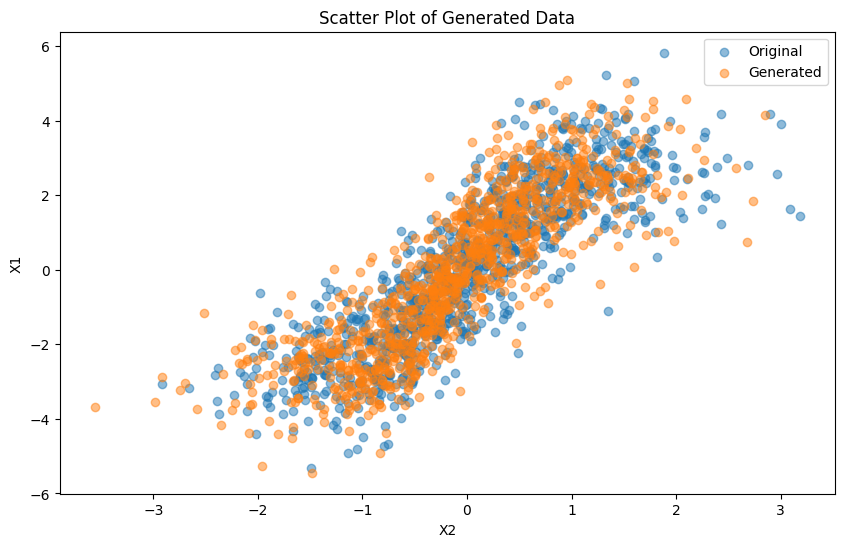

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch

x_idx = 2
y_idx = 1

n = 1000
xs = flow.sample(n)
X_gen = xs[-1].detach().cpu().numpy()
X = carefl.X

plt.figure(figsize=(10, 6))
plt.scatter(X[:, x_idx], X[:, y_idx], alpha=0.5, label='Original')
plt.scatter(X_gen[:, x_idx], X_gen[:, y_idx], alpha=0.5, label='Generated')
plt.xlabel(f'X{x_idx}')
plt.ylabel(f'X{y_idx}')
plt.title('Scatter Plot of Generated Data')
plt.legend()
plt.show()


In [8]:
import plotly.graph_objects as go


xy_idx = [1, 2]
z_idx = 0

# Create figure
fig = go.Figure()

# Add original data scatter plot
fig.add_trace(go.Scatter3d(
    x=X[:, xy_idx[0]],
    y=X[:, xy_idx[1]], 
    z=X[:, z_idx],
    mode='markers',
    name='Original',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Add generated data scatter plot  
fig.add_trace(go.Scatter3d(
    x=X_gen[:, xy_idx[0]],
    y=X_gen[:, xy_idx[1]],
    z=X_gen[:, z_idx],
    mode='markers', 
    name='Generated',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Update layout
fig.update_layout(
    title='3D Scatter Plot of Generated Data (Interactive)',
    scene = dict(
        xaxis_title=f'X{xy_idx[0]}',
        yaxis_title=f'X{xy_idx[1]}',
        zaxis_title=f'X{z_idx}'
    ),
    width=1000,
    height=700
)

#fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Original',
              'type': 'scatter3d',
              'x': {'bdata': ('UqULKz5+87/44WoFVsbxv01rfnrrUv' ... 'ahe3n5P/QeRU4+fQjAgCbYAv07sr8='),
                    'dtype': 'f8'},
              'y': {'bdata': ('ja64Fmus4L9t/qh7gvXGvxD4H+Amfu' ... 'zxFsHsP+9HaNYIiuO/EJpzMvyB7D8='),
                    'dtype': 'f8'},
              'z': {'bdata': ('Abt36hrpC8DBBs/ER7AJwAjglttcUQ' ... 'FNavj9P/dFEOQN7gfAEGBd/LEM4r8='),
                    'dtype': 'f8'}},
             {'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Generated',
              'type': 'scatter3d',
              'x': {'bdata': ('eLzMvzCh3T6eUps/EEUkvnA7vL35cB' ... 'AjGg/ATUerP2SS6r4IS/w+YiIvQA=='),
                    'dtype': 'f4'},
              'y': {'bdata': ('P16cv154fz8Gycc/1WKOvo3F3D7Phs' ... '9DsNG+MGqHP2MQDT9NDWg+q/SEPw=='),
                    'dtype': 'f4'},
              'z': {'bdata': ('mvB9wBT3/T9VrzhA1HL/v2bMNz/Kkk' ... 'C3GTLA6pOCQNJH9798GaU/S24AQA=='),
                    'dtype': 'f4'}}],
    'layout': {'height': 700,
               'scene': {'xaxis': {'title': {'text': 'X1'}},
                         'yaxis': {'title': {'text': 'X2'}},
                         'zaxis': {'title': {'text': 'X0'}}},
               'template': '...',
               'title': {'text': '3D Scatter Plot of Generated Data (Interactive)'},
               'width': 1000}
})

## 1.4 介入生成評価：真モデルの介入平均とCAREFLの介入平均の比較

In [23]:
import importlib 
from carefl.models import carefl

importlib.reload(carefl)

from carefl.models.carefl import CAREFL
import yaml
import argparse

with open('config/config.yaml', 'r') as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
    
def dict2namespace(config):
    namespace = argparse.Namespace()
    for key, value in config.items():
        if isinstance(value, dict):
            new_value = dict2namespace(value)
        else:
            new_value = value
        setattr(namespace, key, new_value)
    return namespace

config = dict2namespace(config_raw)
carefl = CAREFL(config)

In [24]:
flow, loss_vals = carefl._train()

100%|██████████| 200/200 [00:25<00:00,  7.70it/s]


In [25]:
carefl.B_true

array([[0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.]])

In [26]:
int_idx = 1
int_val = 3.0

x_intervened = carefl.predict_intervention(int_idx, int_val, n_samples=1000)

In [27]:
# 真の介入分布からの生成

import importlib

from notears import utils
importlib.reload(utils)

from notears.utils import simulate_nonlinear_sem_with_intervention

x_intervened_true = simulate_nonlinear_sem_with_intervention(carefl.W, np.ones(carefl.meta_data.d) * carefl.meta_data.gam_scale, [int_idx], [int_val], 1000, 'tanh')

In [28]:
import plotly.graph_objects as go


xy_idx = [1, 2]
z_idx = 0

# Create figure
fig = go.Figure()

# Add original data scatter plot
fig.add_trace(go.Scatter3d(
    x=x_intervened_true[:, xy_idx[0]],
    y=x_intervened_true[:, xy_idx[1]], 
    z=x_intervened_true[:, z_idx],
    mode='markers',
    name='Original',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Add generated data scatter plot  
fig.add_trace(go.Scatter3d(
    x=x_intervened[:, xy_idx[0]],
    y=x_intervened[:, xy_idx[1]],
    z=x_intervened[:, z_idx],
    mode='markers', 
    name='Generated',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Update layout
fig.update_layout(
    title='3D Scatter Plot of Generated Data (Interactive)',
    scene = dict(
        xaxis_title=f'X{xy_idx[0]}',
        yaxis_title=f'X{xy_idx[1]}',
        zaxis_title=f'X{z_idx}'
    ),
    width=1000,
    height=700
)

#fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Original',
              'type': 'scatter3d',
              'x': {'bdata': ('AAAAAAAACEAAAAAAAAAIQAAAAAAAAA' ... 'AAAAAIQAAAAAAAAAhAAAAAAAAACEA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('j7loq5tI6j93gYkMASfIP7GrwUSFR/' ... 'Xp2xDvP3cX1Ql6U7C/3jsFpp3ZyL8='),
                    'dtype': 'f8'},
              'z': {'bdata': ('7bvw5DNyCsCNyVGWEjwKwP9PmWts8/' ... 'TadZ30vxqFb+e43gDArzYfFygU9b8='),
                    'dtype': 'f8'}},
             {'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Generated',
              'type': 'scatter3d',
              'x': {'bdata': ('AABAQAAAQEAAAEBAAABAQAAAQEAAAE' ... 'AAAEBAAABAQAAAQEAAAEBAAABAQA=='),
                    'dtype': 'f4'},
              'y': {'bdata': ('SrBcvxgkID5e54+/7acuPuJbBz+sXD' ... 'zNDho/zwXzv/1oF7/OIsW84Q+rvw=='),
                    'dtype': 'f4'},
              'z': {'bdata': ('GGpKwDKtgL/xQ4TAbqaGwPgtZ77FJH' ... 'Bkrj+/UydMwHIXjcClw03AI0KewA=='),
                    'dtype': 'f4'}}],
    'layout': {'height': 700,
               'scene': {'xaxis': {'title': {'text': 'X1'}},
                         'yaxis': {'title': {'text': 'X2'}},
                         'zaxis': {'title': {'text': 'X0'}}},
               'template': '...',
               'title': {'text': '3D Scatter Plot of Generated Data (Interactive)'},
               'width': 1000}
})

# 2. CareFLを用いた反事実的推論

## 2.1 反事実推論の実装

In [38]:
import importlib 
from carefl.models import carefl

importlib.reload(carefl)

from carefl.models.carefl import CAREFL
import yaml
import argparse

with open('config/config.yaml', 'r') as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
    
def dict2namespace(config):
    namespace = argparse.Namespace()
    for key, value in config.items():
        if isinstance(value, dict):
            new_value = dict2namespace(value)
        else:
            new_value = value
        setattr(namespace, key, new_value)
    return namespace

config = dict2namespace(config_raw)
carefl = CAREFL(config)

In [39]:
# データセットの準備と真の潜在変数の取得

from notears.utils import is_dag, simulate_dag, simulate_parameter
import igraph as ig
import numpy as np

d = config.meta_data.d
s0 = config.meta_data.s0
graph_type = config.meta_data.graph_type
n_samples = config.meta_data.n_samples
carefl.B_true = simulate_dag(d, s0, graph_type)
carefl.W = simulate_parameter(carefl.B_true)


def simulate_nonlinear_sem(W, gamma, n, sem_type, noise_scale=None):
    """Simulate samples from non-linear SEM with specified type of noise.

    For uniform, noise z ~ uniform(-a, a), where a = noise_scale.

    Args:
        W (np.ndarray): [d, d] weighted adj matrix of DAG
        gamma (np.ndarray): [d] nonlinearity parameter
        n (int): num of samples, n=inf mimics population risk
        sem_type (str): tanh
        noise_scale (np.ndarray): scale parameter of additive noise, default all ones

    Returns:
        X (np.ndarray): [n, d] sample matrix, [d, d] if n=inf
    """
    def _simulate_single_equation(X, gam, w, scale):
        """X: [n, num of parents], gam: float, w: [num of parents], x: [n]"""
        if sem_type == 'tanh':
            z = np.random.normal(scale=scale, size=n)
            x = gam * np.tanh(X @ w) + z
        else:
            raise ValueError(f'SEM type {sem_type} not supported')
        return x, z
            
    d = W.shape[0]
    if noise_scale is None:
        scale_vec = np.ones(d)
    elif np.isscalar(noise_scale):
        scale_vec = noise_scale * np.ones(d)
    else:
        if len(noise_scale) != d:
            raise ValueError('noise scale must be a scalar or has length d')
        scale_vec = noise_scale
    
    if not is_dag(W):
        raise ValueError('W must be a DAG')
    
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    ordered_vertices = G.topological_sorting()
    assert len(ordered_vertices) == d
    X = np.zeros([n, d])
    Z = []
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        x, z = _simulate_single_equation(X[:, parents], gamma[j], W[parents, j], scale_vec[j])
        X[:, j] = x
        Z.append(z)
    return X, Z

X_obs, Z_obs = simulate_nonlinear_sem(carefl.W, carefl.meta_data.gam_scale * np.ones(d), n_samples, carefl.meta_data.causal_mech)
carefl.X = X_obs


In [40]:
carefl.B_true

array([[0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.]])

In [41]:
# 真の反事実分布から生成


def simulate_nonlinear_sem_with_counterfactual(Z, W, gamma, int_idx, int_val, n, sem_type):
    
    def _simulate_single_equation(z, X, gam, w):
        if sem_type == 'tanh':
            x = gam * np.tanh(X @ w) + z
        else:
            raise ValueError(f'SEM type {sem_type} not supported')
        
        return x
    
    d = W.shape[0]
        
    if not is_dag(W):
        raise ValueError('W must be a DAG')
    
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    ordered_vertices = G.topological_sorting()
    assert len(ordered_vertices) == d
    
    X_cf = np.zeros([n, d])
    for j in ordered_vertices:
        if j in int_idx:
            X_cf[:, j] = int_val[int_idx.index(j)]
        else:
            parents = G.neighbors(j, mode=ig.IN)
            X_cf[:, j] = _simulate_single_equation(Z[j], X_cf[:, parents], gamma[j], W[parents, j])
            
    return X_cf


cf_idx = [1]
cf_val = [3.0]
X_cf = simulate_nonlinear_sem_with_counterfactual(Z_obs, carefl.W, carefl.meta_data.gam_scale * np.ones(d), cf_idx, cf_val, n_samples, 'tanh')

In [42]:
flow, loss_vals = carefl._train(X_obs)

  4%|▍         | 8/200 [00:01<00:24,  7.69it/s]

100%|██████████| 200/200 [00:25<00:00,  7.73it/s]


In [43]:
x_cf = carefl.predict_counterfactual(X_obs, cf_idx, cf_val)

In [44]:
import plotly.graph_objects as go


xy_idx = [0, 1]
z_idx = 2

# Create figure
fig = go.Figure()


# Add original data scatter plot
fig.add_trace(go.Scatter3d(
    x=X_obs[:, xy_idx[0]],
    y=X_obs[:, xy_idx[1]], 
    z=X_obs[:, z_idx],
    mode='markers',
    name='Observed',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

fig.add_trace(go.Scatter3d(
    x=X_cf[:, xy_idx[0]],
    y=X_cf[:, xy_idx[1]], 
    z=X_cf[:, z_idx],
    mode='markers',
    name='True Counterfactual',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Add generated data scatter plot  
fig.add_trace(go.Scatter3d(
    x=x_cf[:, xy_idx[0]],
    y=x_cf[:, xy_idx[1]],
    z=x_cf[:, z_idx],
    mode='markers', 
    name='Counterfactual by CAREFL',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Update layout
fig.update_layout(
    title='3D Scatter Plot of Generated Data (Interactive)',
    scene = dict(
        xaxis_title=f'X{xy_idx[0]}',
        yaxis_title=f'X{xy_idx[1]}',
        zaxis_title=f'X{z_idx}'
    ),
    width=1000,
    height=700
)

#fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Observed',
              'type': 'scatter3d',
              'x': {'bdata': ('HY+gGQIV/j/sNcLIvWgAwBAqa7/KMN' ... '8zY8sLQPpx8hHpDxDAxCbcIqAoB8A='),
                    'dtype': 'f8'},
              'y': {'bdata': ('0Ilu5bLexT88qUMHr+YDQAdojmUoze' ... 'j8UJj3v6+ObpYeK+k/uPkKMigh7z8='),
                    'dtype': 'f8'},
              'z': {'bdata': ('djPm6rBp4T8DK2pdCELuv+o+kUiuMO' ... '2L/5n3Pz/MAvRnkui/a5HqyaVj+L8='),
                    'dtype': 'f8'}},
             {'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'True Counterfactual',
              'type': 'scatter3d',
              'x': {'bdata': ('vgpU1QmjA8DG7tsMI7wOwCK/4dua8g' ... 'HHsSL4vxW271yEJA7Aa8qqyvcUEsA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAACEAAAAAAAAAIQAAAAAAAAA' ... 'AAAAAIQAAAAAAAAAhAAAAAAAAACEA='),
                    'dtype': 'f8'},
              'z': {'bdata': ('xvaVa2C+x7+2nVMjF1vuP8J8LcM5x9' ... 'VkzWHePwu3d4hO3fC/c8WkyA6buj8='),
                    'dtype': 'f8'}},
             {'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Counterfactual by CAREFL',
              'type': 'scatter3d',
              'x': {'bdata': ('uipBwK78CsCMnD/A/zHkvyomVcB00Q' ... 'DWNITAUU/jvwuy5r+sz4HAwWNKwA=='),
                    'dtype': 'f4'},
              'y': {'bdata': ('AABAQAAAQEAAAEBAAABAQAAAQEAAAE' ... 'AAAEBAAABAQAAAQEAAAEBAAABAQA=='),
                    'dtype': 'f4'},
              'z': {'bdata': ('h00LP0MQcr9yhQE/AiFwP35wDMASDE' ... '5uozO/A2GtP/zPvD9Ak0S/Lh3Dvw=='),
                    'dtype': 'f4'}}],
    'layout': {'height': 700,
               'scene': {'xaxis': {'title': {'text': 'X0'}},
                         'yaxis': {'title': {'text': 'X1'}},
                         'zaxis': {'title': {'text': 'X2'}}},
               'template': '...',
               'title': {'text': '3D Scatter Plot of Generated Data (Interactive)'},
               'width': 1000}
})

## 2.2 反事実推論モジュールの動作確認

In [46]:
import importlib
from notears import utils

importlib.reload(utils)

from notears.utils import is_dag, simulate_dag, simulate_parameter, simulate_nonlinear_sem, simulate_nonlinear_sem_with_counterfactual

n = 1000
d = 3
s0 = 3
graph_type = 'ER'
gam_scale = 3.0
gamma = gam_scale * np.ones(d)

B_true = simulate_dag(d, s0, graph_type)
W_true = simulate_parameter(B_true)
X_obs, Z_obs = simulate_nonlinear_sem(W_true, gamma, n, 'tanh', use_z=True)


In [47]:
B_true

array([[0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.]])

In [48]:
cf_idx = [1]
cf_val = [3.0]
X_cf = simulate_nonlinear_sem_with_counterfactual(Z_obs, W_true, gamma, cf_idx, cf_val, n, 'tanh')

In [49]:
import plotly.graph_objects as go


xy_idx = [0, 1]
z_idx = 2

# Create figure
fig = go.Figure()


# Add original data scatter plot
fig.add_trace(go.Scatter3d(
    x=X_obs[:, xy_idx[0]],
    y=X_obs[:, xy_idx[1]], 
    z=X_obs[:, z_idx],
    mode='markers',
    name='Observed',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

fig.add_trace(go.Scatter3d(
    x=X_cf[:, xy_idx[0]],
    y=X_cf[:, xy_idx[1]], 
    z=X_cf[:, z_idx],
    mode='markers',
    name='True Counterfactual',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Update layout
fig.update_layout(
    title='3D Scatter Plot of Generated Data (Interactive)',
    scene = dict(
        xaxis_title=f'X{xy_idx[0]}',
        yaxis_title=f'X{xy_idx[1]}',
        zaxis_title=f'X{z_idx}'
    ),
    width=1000,
    height=700
)

#fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Observed',
              'type': 'scatter3d',
              'x': {'bdata': ('4HV0GYi39j9MBSWnpVYPQHGX0mcOcg' ... 'yH23EKQPAc6yA9jwxA36sEakJzEEA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('dNU6LqV3BMDIYhawLHf9v2v1UO9xx9' ... 'nkh50JwHWXtHpTKvS/1A67pEpQEMA='),
                    'dtype': 'f8'},
              'z': {'bdata': ('vUYMzy4a8r8QorUmIoTbv9Kg477joL' ... 'LcvQj3vy8mfn++IdC/9+mUGs1b7b8='),
                    'dtype': 'f8'}},
             {'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'True Counterfactual',
              'type': 'scatter3d',
              'x': {'bdata': ('n1sbY2ErEMCl/ToaaHALwINBaVfxUA' ... 'Iy18ERwG7v4Mr1AwrAhTirJuNWD8A='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAACEAAAAAAAAAIQAAAAAAAAA' ... 'AAAAAIQAAAAAAAAAhAAAAAAAAACEA='),
                    'dtype': 'f8'},
              'z': {'bdata': ('wudnLAdI+b/I3zwrZZXtP9MIu69hTf' ... 'Il947TP/SYMVtqZOQ/F/i0BAzN8T8='),
                    'dtype': 'f8'}}],
    'layout': {'height': 700,
               'scene': {'xaxis': {'title': {'text': 'X0'}},
                         'yaxis': {'title': {'text': 'X1'}},
                         'zaxis': {'title': {'text': 'X2'}}},
               'template': '...',
               'title': {'text': '3D Scatter Plot of Generated Data (Interactive)'},
               'width': 1000}
})